# Plots to differentiate models

Conda environment for this notebook is in `development/plots/environment.yml`


## Plots of training sequences


In [1]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd


# standardize colors
from cycler import cycler 
colors = [ "#3e6990", "#aabd8c", "#8a8565", "#f39b6d","#381d2a",]
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)


# Fonts match with latex
matplotlib.rcParams.update({
    'font.family': 'serif',
})

In [2]:
nrows, ncols = 1, 1

config = [
    {"labelname": "AdaptiveHP", "filepath":
     "../pixsplit_hgq2/Training_AdaptiveHP/pixsplit_hgq2_Training_AdaptiveHP_log.csv"},
]

data = [
    {
        "labelname": line["labelname"],
        "dataframe": pd.read_csv(line['filepath'], sep=';', index_col=0),
    }
    for line in config
]

data[0]
#df = data[1]["dataframe"]
#df[:10]

{'labelname': 'AdaptiveHP',
 'dataframe':        accuracy      beta   ebops  learning_rate      loss  val_accuracy  \
 epoch                                                                      
 0      0.595950  0.000001  759323       0.005000  1.726249      0.701255   
 1      0.681633  0.000001  521125       0.005000  1.347699      0.710067   
 2      0.698512  0.000001  390112       0.005000  1.124619      0.728652   
 3      0.711413  0.000001  300951       0.005000  0.986594      0.708992   
 4      0.708794  0.000001  251680       0.004999  0.928823      0.719803   
 ...         ...       ...     ...            ...       ...           ...   
 1888   0.665601  0.000071    1012       0.000344  0.776092      0.677642   
 1889   0.666618  0.000071     993       0.000336  0.778995      0.675155   
 1890   0.660190  0.000071     978       0.000329  0.789257      0.674913   
 1891   0.666397  0.000071    1004       0.000322  0.779846      0.676320   
 1892   0.665333  0.000071    1013 

### Accuracy over Ebops

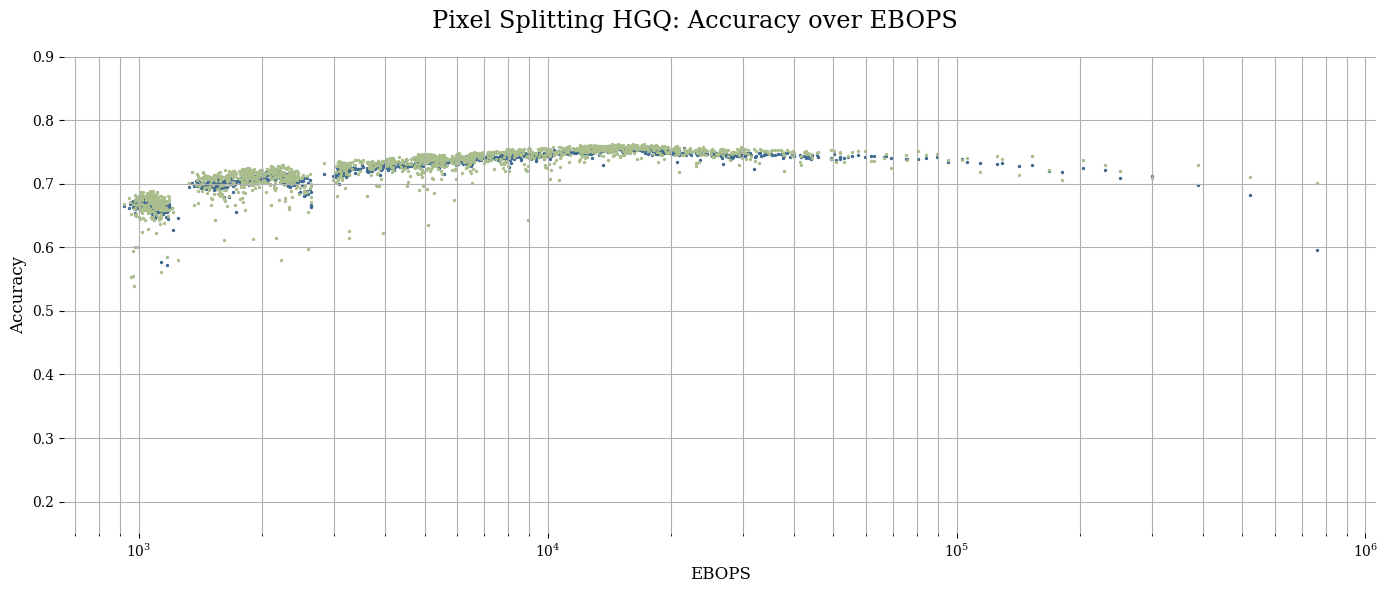

In [7]:
plotname = "Pixel Splitting HGQ: Accuracy over EBOPS"
fig, ax = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 6))

item = data[0]

df = item['dataframe']

ax.scatter('ebops', 'accuracy', data=df, color=colors[0], s=2)#, alpha=0.5)
ax.scatter('ebops', 'val_accuracy', data=df, color=colors[1], s=2)
ax.set_xscale("log")
#ax1.set_xlim(50)

#ax1.semilogx('ebops', 'accuracy', data=df)
#ax1.plot('ebops', 'accuracy', data=df, color=colors[0])
#ax1.set_xlim(0,1000)

ax.set_ylim(0.15, 0.9) # tilpasset data
ax.grid(True, which='both')

#ax.set_title(item['labelname'],size='x-large')
ax.set_xlabel('EBOPS', size='large')
ax.set_ylabel('Accuracy', size='large')

for spine in ("right", "top",
            "left", "bottom"
            ):
    ax.spines[spine].set_visible(False)



plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight") #so many dots lol
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")


### Accuracy and EBOPS over Epochs (timeseries)

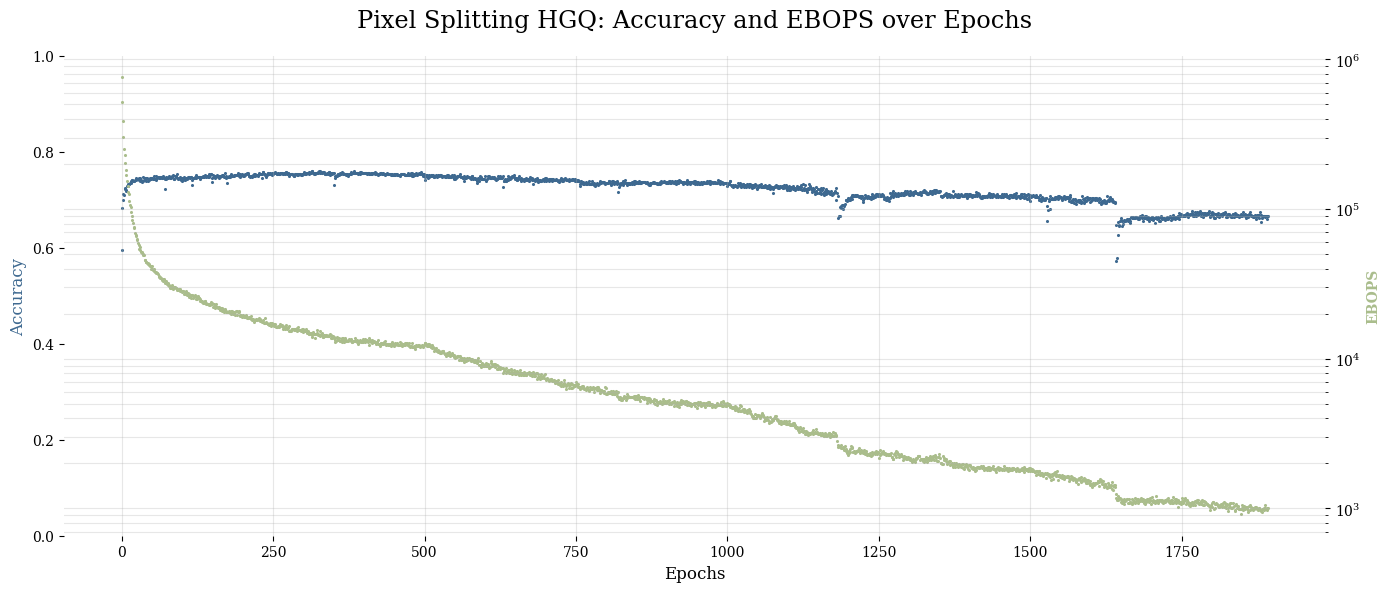

In [6]:
plotname = "Pixel Splitting HGQ: Accuracy and EBOPS over Epochs"
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,figsize=(14, 6))


item = data[0]

ax = axs
ax2 = ax.twinx()
df = item['dataframe']

#ax1.plot(df.index, 'accuracy', data=df, color=colors[0])
ax.scatter(df.index, 'accuracy', data=df, color=colors[0], s=1.5)
ax.set_ylim(0, 1)

#ax2.semilogy(df.index, 'ebops', data=df, color=colors[1])
ax2.scatter(df.index, 'ebops', data=df, color=colors[1], s=1.5)
ax2.set_yscale("log")

#ax.set_title(item['labelname'],size='x-large')
ax.set_xlabel('Epochs', size='large')
ax.set_ylabel('Accuracy', color=colors[0], size='large')
ax2.set_ylabel('EBOPS', color=colors[1], weight='bold')
ax.grid(True, which='both', alpha=0.3, axis='x')
ax2.grid(True, which='both', alpha=0.3)
for spine in ("right", "top",
                "left", "bottom"
                ):
    ax.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)
#ax2.grid()

    
plt.suptitle(plotname, size = 'xx-large')#, weight = 'bold')
plt.tight_layout()
plt.show()
fig.savefig(f"export/{plotname.lower()}.pdf", format='pdf', bbox_inches="tight")
fig.savefig(f"export/{plotname.lower()}.png", dpi=300, bbox_inches="tight")

# Annotations https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotate_transform.html
# Minimalistic https://practicaldatascience.org/notebooks/class_5/week_1/2.2.2_making_plots_pretty_2.html